Number of duplicate rows: 0
Train prepared shape: (657320, 476)
Validation prepared shape: (164331, 476)
Test prepared shape: (205413, 476)
Validation Set Classification Report:
              precision    recall  f1-score   support

           A       0.89      0.93      0.91      8106
           B       0.99      0.95      0.97     32156
           C       0.96      0.97      0.96     13438
           K       0.39      1.00      0.56      1068
           O       1.00      0.99      1.00    109563

    accuracy                           0.98    164331
   macro avg       0.85      0.97      0.88    164331
weighted avg       0.98      0.98      0.98    164331



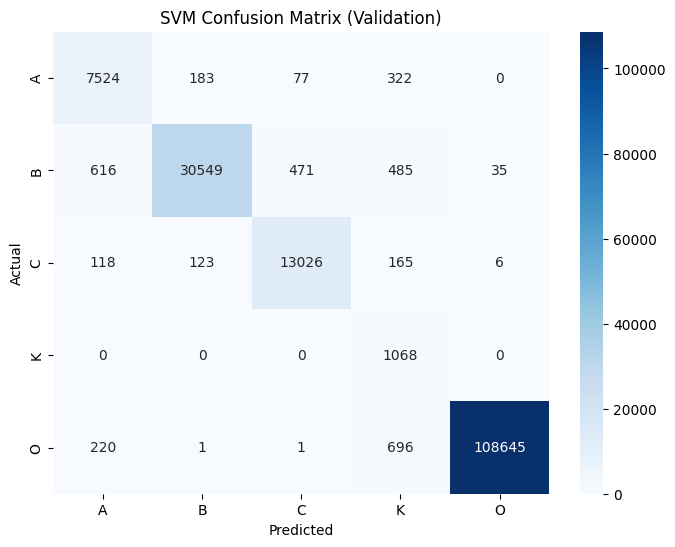

Test Set Classification Report:
              precision    recall  f1-score   support

           A       0.89      0.93      0.91     10132
           B       0.99      0.95      0.97     40196
           C       0.96      0.97      0.96     16797
           K       0.41      1.00      0.58      1335
           O       1.00      0.99      1.00    136953

    accuracy                           0.98    205413
   macro avg       0.85      0.97      0.88    205413
weighted avg       0.98      0.98      0.98    205413



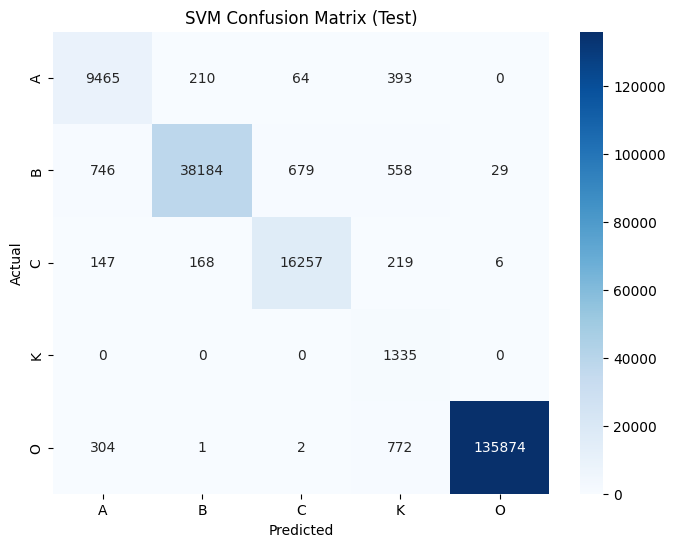

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier

# ----- Data Loading and Cleaning -----
def load_crash_data(csv_filename="Crash_Data.csv"):
    crash = pd.read_csv(csv_filename, engine='python', on_bad_lines='skip')
    crash.columns = crash.columns.str.strip()
    crash = crash.dropna(subset=['CRASH_SEVERITY'])
    return crash

crash = load_crash_data()

# Check for duplicates
duplicate_count = crash.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# ----- Data Splitting -----
# Split out the test set (20%) using stratification on the target
train_val_set, test_set = train_test_split(crash, test_size=0.2, random_state=42, stratify=crash['CRASH_SEVERITY'])
# Split train_val_set into training (80%) and validation (20%)
train_set, validation_set = train_test_split(train_val_set, test_size=0.2, random_state=42, stratify=train_val_set['CRASH_SEVERITY'])

# Separate target from features
train_labels = train_set['CRASH_SEVERITY'].copy()
train_set = train_set.drop('CRASH_SEVERITY', axis=1)

validation_labels = validation_set['CRASH_SEVERITY'].copy()
validation_set = validation_set.drop('CRASH_SEVERITY', axis=1)

test_labels = test_set['CRASH_SEVERITY'].copy()
test_set = test_set.drop('CRASH_SEVERITY', axis=1)

# ----- Preprocessing Pipeline -----
# Identify numeric and categorical columns
numeric = train_set.select_dtypes(include=['float64', 'int64'])
categorical = train_set.select_dtypes(include=['object'])

num_attribs = list(numeric.columns)
cat_attribs = list(categorical.columns)

# Numeric pipeline: imputation and scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Full pipeline combining numeric and categorical processing
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(handle_unknown='ignore', max_categories=50), cat_attribs)
])

# Fit the pipeline on the training set only, then transform training, validation, and test sets
train_prepared = full_pipeline.fit_transform(train_set)
validation_prepared = full_pipeline.transform(validation_set)
test_prepared = full_pipeline.transform(test_set)

# # Print the shapes to verify
print("Train prepared shape:", train_prepared.shape)
print("Validation prepared shape:", validation_prepared.shape)
print("Test prepared shape:", test_prepared.shape)

# ----- PCA and SVM Pipeline -----
# Optionally reduce dimensionality with PCA to speed up SVM training
pca = PCA(n_components=20)

# Create a pipeline that includes preprocessing, PCA, and the SVM classifier
model_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('pca', pca),
    ('nystroem', Nystroem(kernel='rbf', n_components=100, random_state=42)),
    ('sgd', SGDClassifier(loss='hinge', class_weight='balanced', max_iter=1000, tol=1e-3))
])

# ----- Train the Model -----
model_pipeline.fit(train_set, train_labels)

# ----- Evaluate on the Validation Set -----
val_predictions = model_pipeline.predict(validation_set)
print("Validation Set Classification Report:")
print(classification_report(validation_labels, val_predictions))

cm_val = confusion_matrix(validation_labels, val_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(validation_labels),
            yticklabels=np.unique(validation_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix (Validation)')
plt.show()

# ----- Evaluate on the Test Set -----
test_predictions = model_pipeline.predict(test_set)
print("Test Set Classification Report:")
print(classification_report(test_labels, test_predictions))

cm_test = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(test_labels),
            yticklabels=np.unique(test_labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix (Test)')
plt.show()

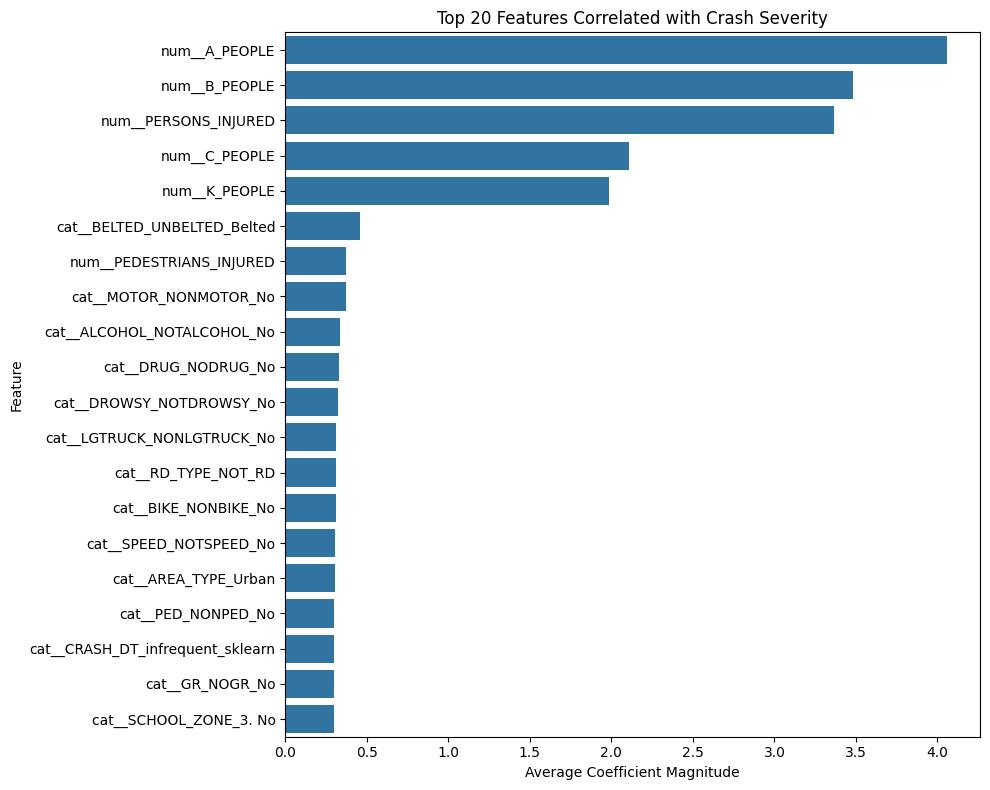


Top 50 features:
                                                      Feature  Importance
                                                num__A_PEOPLE    4.058020
                                                num__B_PEOPLE    3.479957
                                         num__PERSONS_INJURED    3.366713
                                                num__C_PEOPLE    2.107539
                                                num__K_PEOPLE    1.988459
                                  cat__BELTED_UNBELTED_Belted    0.459968
                                     num__PEDESTRIANS_INJURED    0.373989
                                       cat__MOTOR_NONMOTOR_No    0.370712
                                   cat__ALCOHOL_NOTALCOHOL_No    0.337140
                                          cat__DRUG_NODRUG_No    0.330504
                                     cat__DROWSY_NOTDROWSY_No    0.324942
                                   cat__LGTRUCK_NONLGTRUCK_No    0.312567
                    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Train a Linear Model for Interpretability -----
# Replace SVM with Logistic Regression for feature importance
interpretable_pipeline = Pipeline([
    ('preprocessing', full_pipeline),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Fit the model
interpretable_pipeline.fit(train_set, train_labels)

# ----- Extract Feature Importances -----
# Get feature names after encoding and scaling
feature_names = interpretable_pipeline.named_steps['preprocessing'].get_feature_names_out()

# Get model coefficients (for multiclass: one row per class)
coef_matrix = interpretable_pipeline.named_steps['classifier'].coef_

# Compute average absolute importance across all classes
importance = np.abs(coef_matrix).mean(axis=0)

# Create a dataframe to sort and visualize
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Display top 20 features
top_k = 20
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importances.head(top_k), x='Importance', y='Feature')
plt.title(f'Top {top_k} Features Correlated with Crash Severity')
plt.xlabel('Average Coefficient Magnitude')
plt.tight_layout()
plt.show()

# Optionally print the full ranked list
print("\nTop 50 features:")
print(feature_importances.head(50).to_string(index=False))

In [ ]:
duplicate_rows = crash.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)


In [ ]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(train_prepared, train_labels)
dummy_preds = dummy.predict(validation_prepared)
print(classification_report(validation_labels, dummy_preds))
